In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

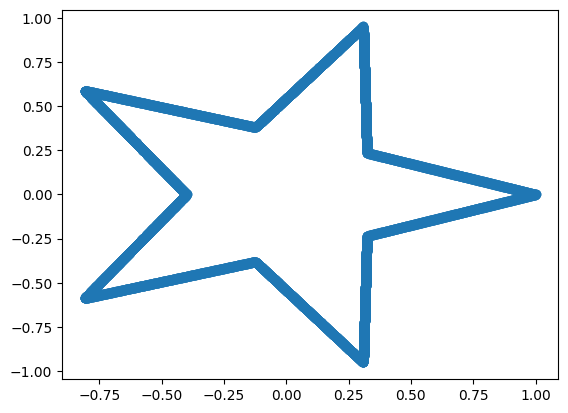

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [11]:
class Config:
    beta_min = 0.01
    beta_max = 2.0
    mode='uniform'

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [7]:
def beta_t(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def log_alpha_t(t, config):
    return -0.25 * (config.beta_max - config.beta_min) * t**2 - 0.5 * config.beta_min * t

def alpha_t(t, config):
    return torch.exp(log_alpha_t(t, config))

def std_t(t, config):
    a = alpha_t(t, config)
    return torch.sqrt(1.0 - a**2 + 1e-5)

In [8]:
def loss_weight(t, sigma, config, mode='uniform', eps=1e-4):
    if mode == 'uniform':
        w = torch.ones_like(t)
    elif mode == 'sigma2':
        w = sigma ** 2
    elif mode == 'beta':
        w = beta_t(t, config)
    elif mode == 'inv_sigma2':
        w = 1.0 / (sigma ** 2 + eps)
    return w


In [14]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
        self.mode = self.config.mode

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            a = alpha_t(t, self.config)
            s = std_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = a * batch + s * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            w = loss_weight(t, s, self.config, mode=self.mode)
            per_sample = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            loss = (w * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        total_loss = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            total_loss.append(loss)
            if n % 100 == 0:
                print(f'Loss: {loss}')
        return total_loss

In [15]:
config = Config()
trainer = VETrainer(config)

In [17]:
losses = {}

In [18]:
losses["base"] = trainer.run()

Loss: 0.43400784282684324
Loss: 0.4310535291194916
Loss: 0.43520819573402403
Loss: 0.45446518745422365
Loss: 0.44802438988685606
Loss: 0.4286710177898407
Loss: 0.4346437257766724
Loss: 0.43856709904670715
Loss: 0.4432828869819641
Loss: 0.43830407433509827
Loss: 0.4600550476074219
Loss: 0.43626523675918577
Loss: 0.4367189561843872
Loss: 0.43642054262161256
Loss: 0.43788217091560366
Loss: 0.433813231086731
Loss: 0.4496784390926361
Loss: 0.43347527194023133
Loss: 0.4406844260215759
Loss: 0.43305062379837034


In [19]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps
        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t_tensor, config)
            std = std_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / std

            drift = (-0.5 * beta * x - beta * score) * dt
            diffusion = torch.sqrt(beta) * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [20]:
samples = sample(trainer.model, trainer.config, 1000)

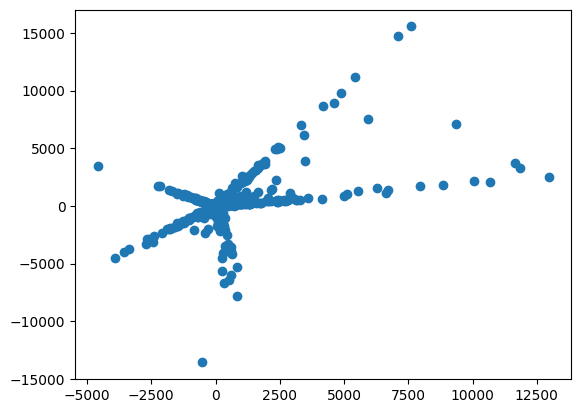

In [21]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

# попробуем разные виды взвешивания лоссов

сделаем через взвешивать через $\sigma^2$

In [22]:
config = Config()
config.mode = 'sigma2'
trainer = VETrainer(config)

In [23]:
losses["sigma2"] = trainer.run()

Loss: 0.23875305407047273
Loss: 0.07627181329727173
Loss: 0.0749778842329979
Loss: 0.07280011522769927
Loss: 0.07428956452608108
Loss: 0.07149808342456818
Loss: 0.07356065675020218
Loss: 0.07081331243515014
Loss: 0.0740053838968277
Loss: 0.07494353858232498
Loss: 0.074822376704216
Loss: 0.071629099714756
Loss: 0.07340122275352479
Loss: 0.07342566151618958
Loss: 0.07179008493423462
Loss: 0.07301715281009674
Loss: 0.07265810947418212
Loss: 0.0734319473862648
Loss: 0.07427170810699463
Loss: 0.07302873730659484


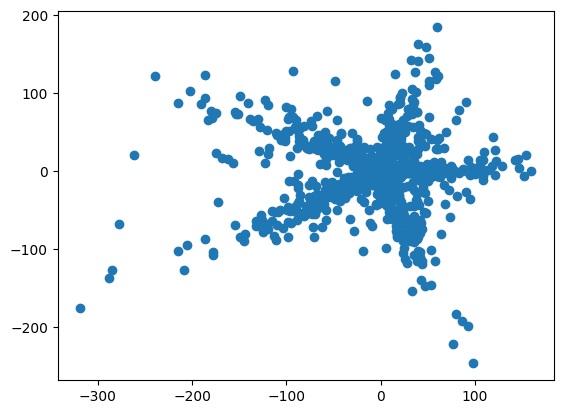

In [24]:
samples = sample(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Мне кажется по качеству стало сильно лучше, разброс стал в разы меньше

попробуем теперь beta

In [25]:
config = Config()
config.mode = 'beta'
trainer = VETrainer(config)

In [26]:
losses["beta"] = trainer.run()

Loss: 0.9041528562545776
Loss: 0.36692914481163025
Loss: 0.3590280272960663
Loss: 0.33867279801368716
Loss: 0.34372120208740237
Loss: 0.3401112195968628
Loss: 0.33387182354927064
Loss: 0.3323048605918884
Loss: 0.333885502243042
Loss: 0.3377172063827515
Loss: 0.33164029293060304
Loss: 0.32592545070648193
Loss: 0.3212354529380798
Loss: 0.3328844779968262
Loss: 0.3430587616443634
Loss: 0.32283467655181886
Loss: 0.33911986603736877
Loss: 0.3293909855365753
Loss: 0.3258318770885468
Loss: 0.3276931399345398


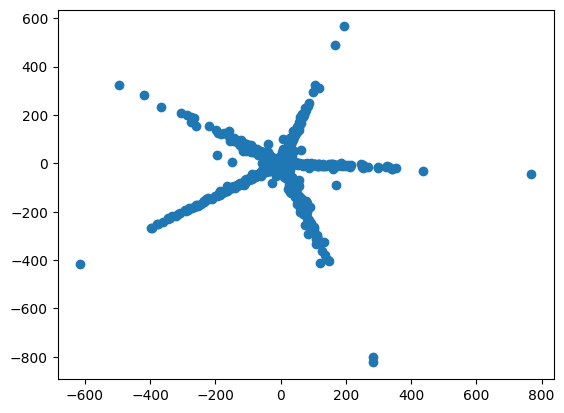

In [27]:
samples = sample(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Так, здесь у нас разброс такой же большой как на бейзлайне, но распределение стало равномернее

теперь попробуем через $\frac{1}{\sigma^2}$

In [28]:
config = Config()
config.mode = 'inv_sigma2'
trainer = VETrainer(config)

In [29]:
losses["inv_sigma2"] = trainer.run()

Loss: 118.86620498046875
Loss: 107.73399123535157
Loss: 120.3917453125
Loss: 108.25326473388672
Loss: 116.30316872558593
Loss: 103.69901687011719
Loss: 106.35893892822266
Loss: 107.27632306518555
Loss: 103.08539293212891
Loss: 109.92198117675781
Loss: 113.69740516357422
Loss: 138.33911525878906
Loss: 97.94607935791015
Loss: 114.16570290527343
Loss: 116.85524093017578
Loss: 99.93742236328124
Loss: 105.10786916503906
Loss: 98.0877716796875
Loss: 133.3611446777344
Loss: 105.53469428710937


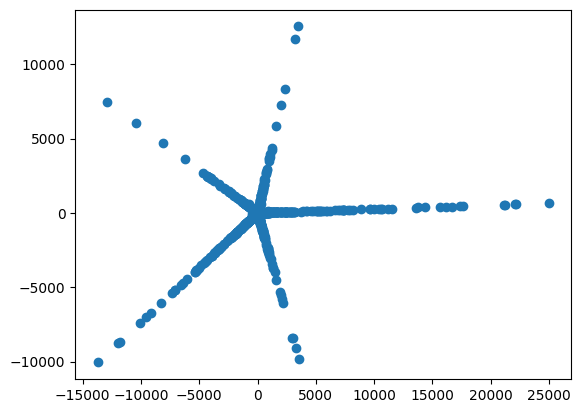

In [30]:
samples = sample(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Разброс теперь ещё больше, но шумных обьектов стало меньше, возможно дело в масштабе и на нем шум незаметен

Сравним графики лоссов

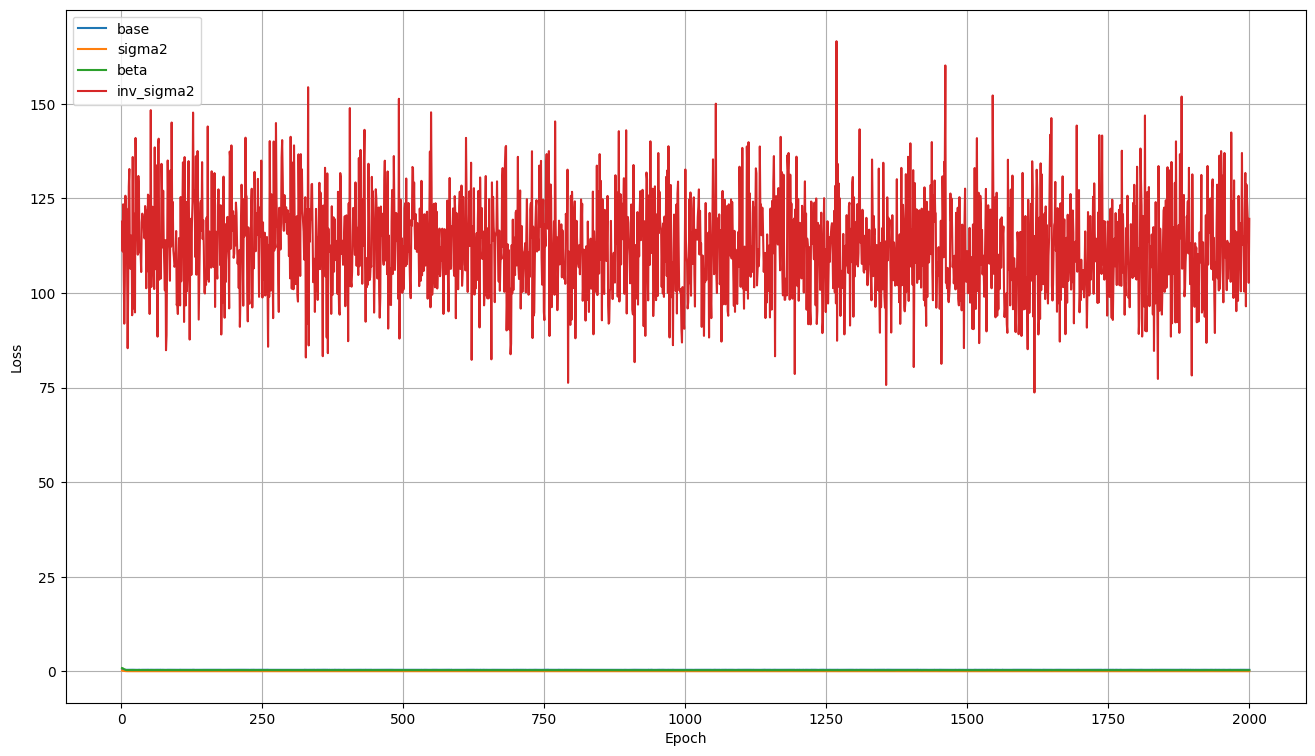

In [35]:
plt.figure(figsize=(16,9))
epochs = range(1, 2001)
for name, loss in losses.items():
    plt.plot(epochs, loss, label=name)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.legend()
plt.show()

посмотрим на лоссы без обратной сигмы

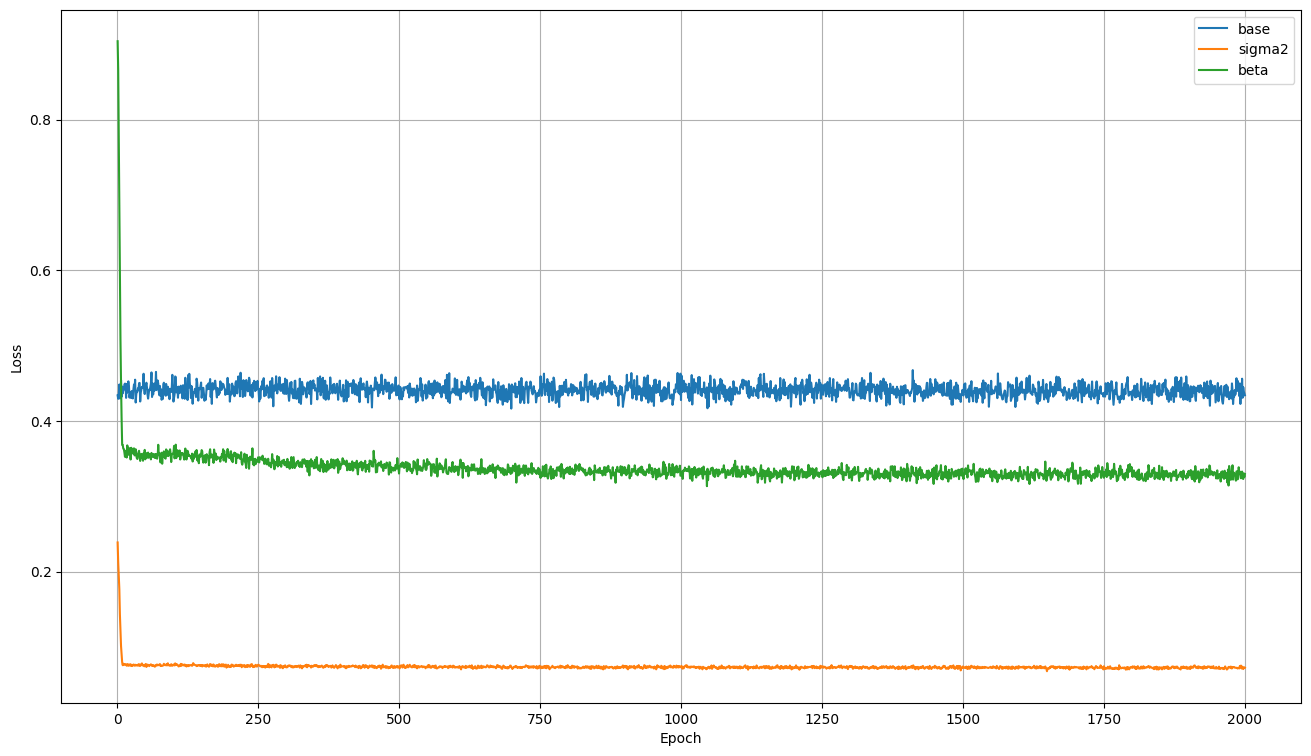

In [36]:
plt.figure(figsize=(16,9))
epochs = range(1, 2001)
for name, loss in losses.items():
    if name != 'inv_sigma2':
        plt.plot(epochs, loss, label=name)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()

И по лоссу, и по качеству лучшим оказалось взвешивание через $\sigma^2$. Она имеет наименьший разброс значений точек на нашей звездочке с небольшим количеством шума. Остальные кандидаты показали себя хуже, хоть и $\frac{1}{\sigma^2}$ был наименее шумным относительно всех, но с самым высоким разбросом.

# сравним расписания

In [37]:
def cosine_alpha_bar_t(t, s=0.008):
    t = torch.clamp(t, 0.0, 1.0)
    f_t = torch.cos((t + s) / (1 + s) * torch.pi / 2) ** 2
    f_0 = torch.cos(torch.tensor(s / (1 + s) * torch.pi / 2, device=t.device)) ** 2
    return f_t / f_0


def cosine_alpha_t(t, config=None, s=0.008):
    alpha_bar = cosine_alpha_bar_t(t, s=s)
    return torch.sqrt(torch.clamp(alpha_bar, min=1e-6, max=1.0))


def cosine_std_t(t, config=None, s=0.008):
    alpha_bar = cosine_alpha_bar_t(t, s=s)
    return torch.sqrt(torch.clamp(1.0 - alpha_bar, min=1e-6, max=1.0))


def cosine_beta_t(t, config=None, s=0.008):
    t = torch.clamp(t, 1e-5, 1.0 - 1e-5)
    u = (t + s) / (1 + s)
    beta = (torch.pi / (1 + s)) * torch.tan(u * torch.pi / 2)
    return torch.clamp(beta, max=50.0)


In [38]:
class VETrainer1():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
        self.mode = self.config.mode

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            a = cosine_alpha_t(t, self.config)
            s = cosine_std_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = a * batch + s * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            w = loss_weight(t, s, self.config, mode=self.mode)
            per_sample = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            loss = (w * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        total_loss = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            total_loss.append(loss)
            if n % 100 == 0:
                print(f'Loss: {loss}')
        return total_loss

In [39]:
def sample1(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps
        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = cosine_beta_t(t_tensor, config)
            std = cosine_std_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / std

            drift = (-0.5 * beta * x - beta * score) * dt
            diffusion = torch.sqrt(torch.clamp(beta, min=1e-5)) * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [41]:
config = Config()
config.mode = 'sigma2'
trainer = VETrainer1(config)

In [42]:
losses['sigma2_cosine'] = trainer.run()

Loss: 0.44949351382255553
Loss: 0.05569498824477196
Loss: 0.05642580010890961
Loss: 0.05404364067316055
Loss: 0.057140612256526946
Loss: 0.054996200054883954
Loss: 0.05589306873083115
Loss: 0.0547019980430603
Loss: 0.05357941300272941
Loss: 0.0548950247168541
Loss: 0.05509847741127014
Loss: 0.054077922612428664
Loss: 0.05472524544596672
Loss: 0.055287231802940366
Loss: 0.05475171893239021
Loss: 0.05447637809514999
Loss: 0.0548757820546627
Loss: 0.05497694247961044
Loss: 0.05384373337626457
Loss: 0.05373699073791504


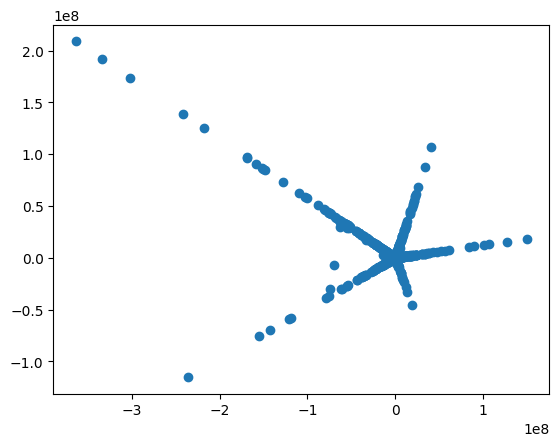

In [43]:
samples = sample1(trainer.model, trainer.config, 1000)
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

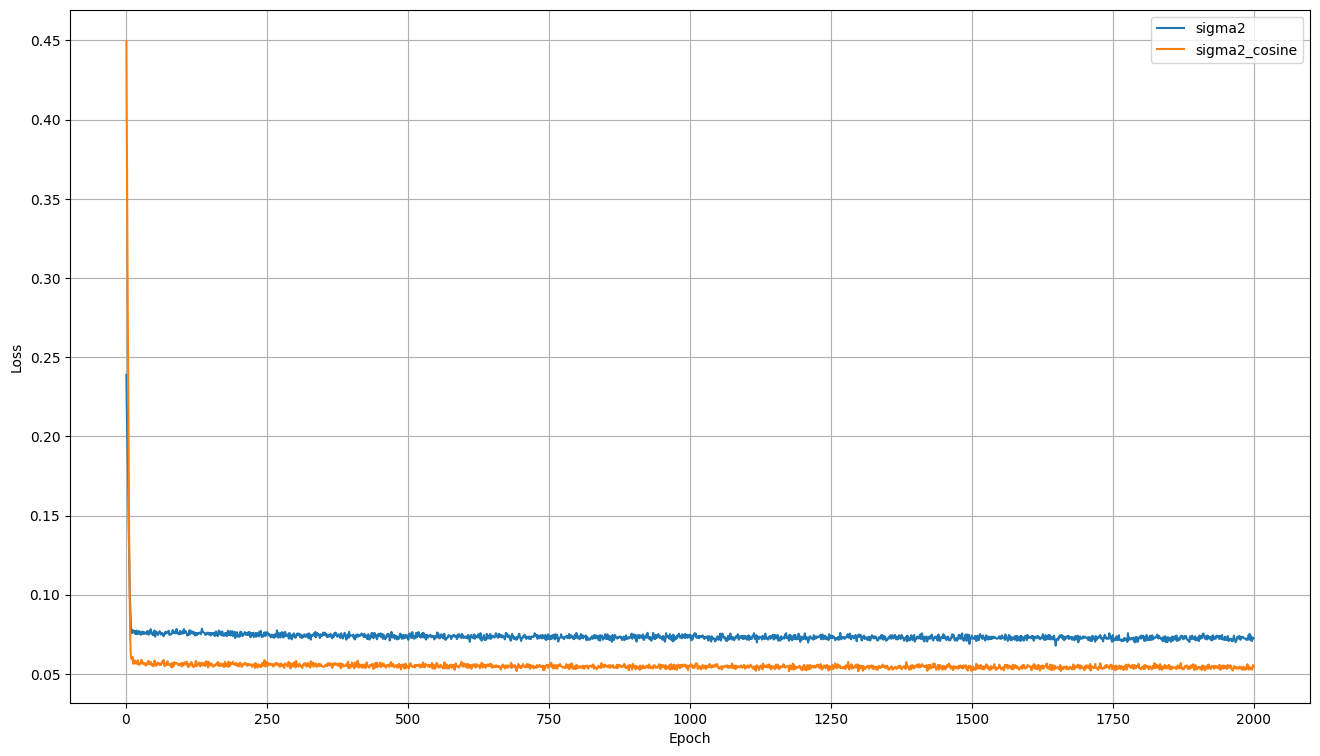

In [44]:
plt.figure(figsize=(16,9))
epochs = range(1, 2001)
plt.plot(epochs, losses['sigma2'], label='sigma2')
plt.plot(epochs, losses['sigma2_cosine'], label='sigma2_cosine')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()

Так, ну косинусное расписание уже больше порадовало, разброс минимален, шума очень мало, думаю, что с косинусным расстоянием вышло оптимальней всего